In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df = pd.read_csv("D:/Credit-Risk-Scoring-System/data/raw/german_credit_data.csv")
print(df)

     Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0             0   67    male    2     own             NaN           little   
1             1   22  female    2     own          little         moderate   
2             2   49    male    1     own          little              NaN   
3             3   45    male    2    free          little           little   
4             4   53    male    2    free          little           little   
..          ...  ...     ...  ...     ...             ...              ...   
995         995   31  female    1     own          little              NaN   
996         996   40    male    3     own          little           little   
997         997   38    male    2     own          little              NaN   
998         998   23    male    2    free          little           little   
999         999   27    male    2     own        moderate         moderate   

     Credit amount  Duration              Purpose  Risk  
0    

In [114]:
# Basic info
print(df.shape)

(1000, 11)


In [115]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [116]:
# Column names
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [117]:
# Data types
df.dtypes

Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

In [118]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [119]:
for col in df.columns:
    if df[col].nunique()<20:
        print(df[col].value_counts())
        print('-'*50)

Sex
male      690
female    310
Name: count, dtype: int64
--------------------------------------------------
Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64
--------------------------------------------------
Housing
own     713
rent    179
free    108
Name: count, dtype: int64
--------------------------------------------------
Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
--------------------------------------------------
Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64
--------------------------------------------------
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
--------------------------------------------------
Risk
good    700
bad     300
Name: count, dty

Missing Value Checks

In [120]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [121]:
df.isnull().sum()/len(df)*100

Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64

In [122]:
df.isnull().sum().sort_values(ascending=False)

Checking account    394
Saving accounts     183
Unnamed: 0            0
Sex                   0
Age                   0
Housing               0
Job                   0
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Duplicate check

In [123]:
df[df.duplicated()].shape# means nothing is duplicated

(0, 11)

In [124]:
df[df.duplicated()]


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk


Statistical Summary

In [125]:
df.describe()


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [126]:
df.describe(include='object')

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


Target Variable Analysis

In [127]:
# Target distribution
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

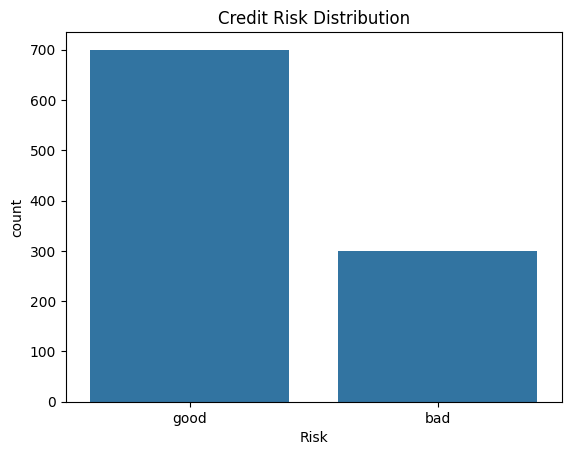

In [128]:
sns.countplot(x='Risk', data=df)
plt.title("Credit Risk Distribution")
plt.show()

Numerical Feature Analysis

In [129]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration'], dtype='object')

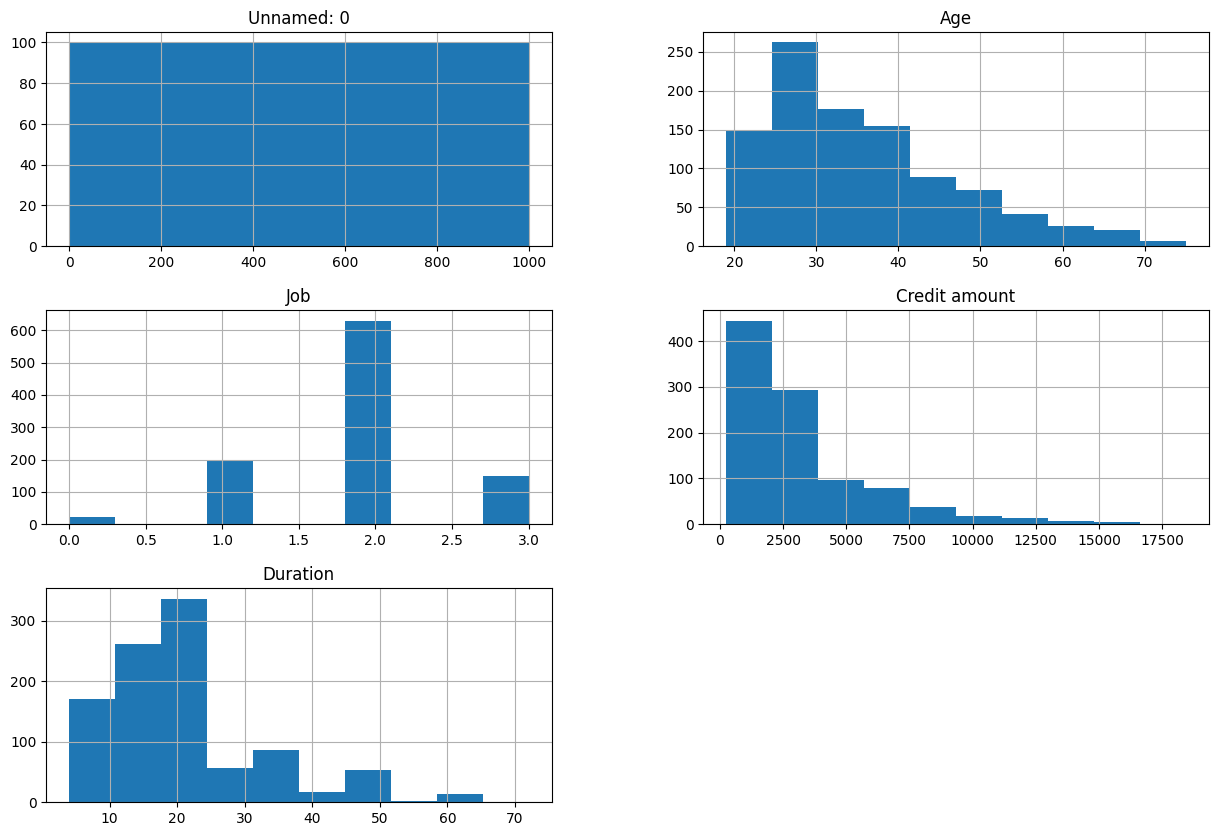

In [130]:
df[num_cols].hist(figsize=(15,10))
plt.show()

Categorical Feature Analysis

In [131]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose',
       'Risk'],
      dtype='object')

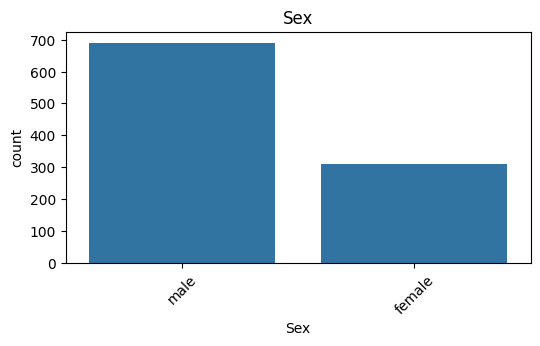

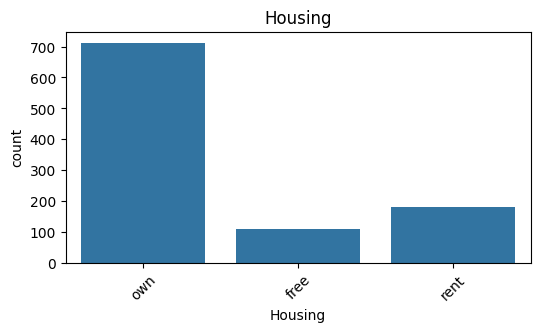

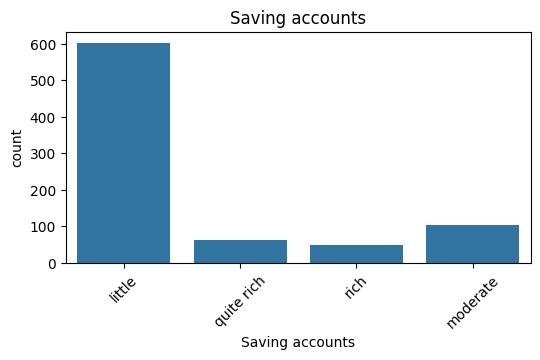

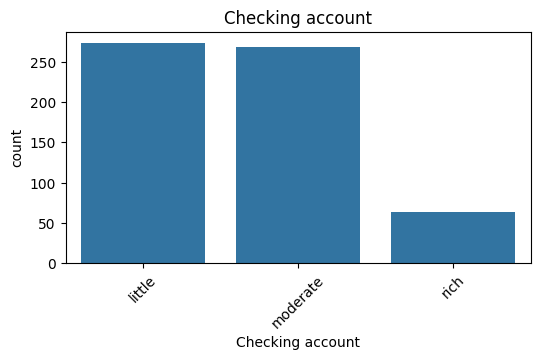

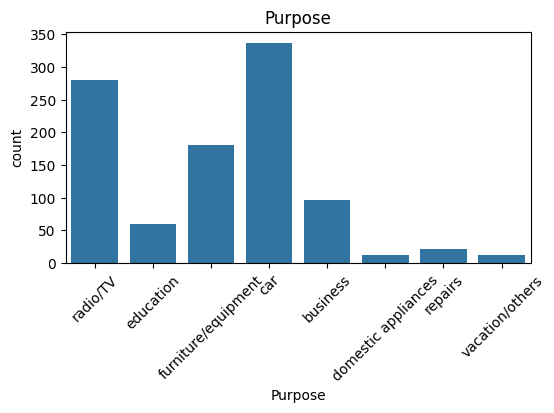

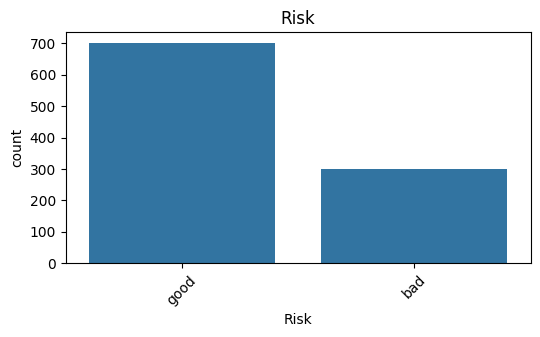

In [132]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

Correlation Analysis

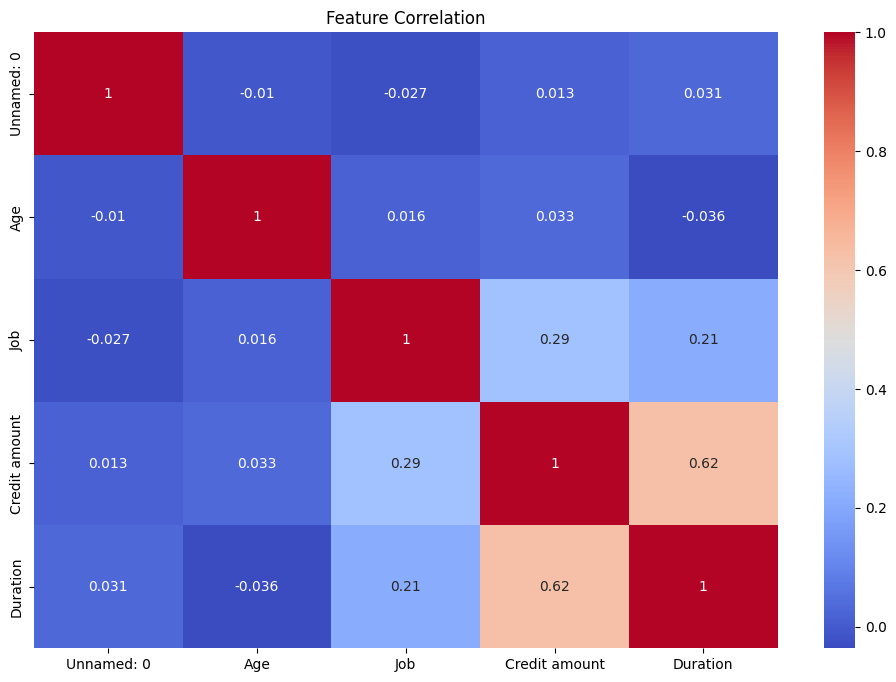

In [133]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Risk vs Features

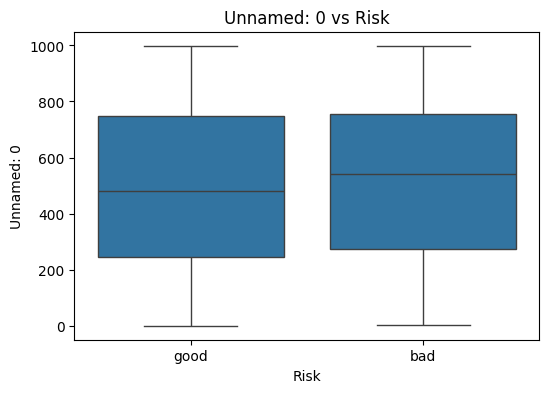

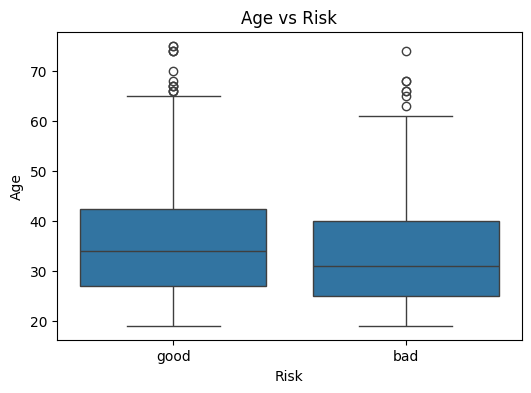

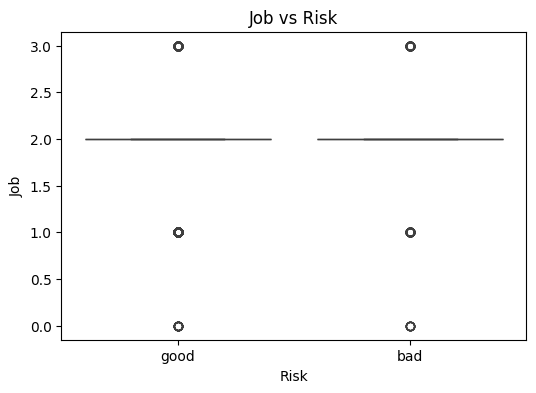

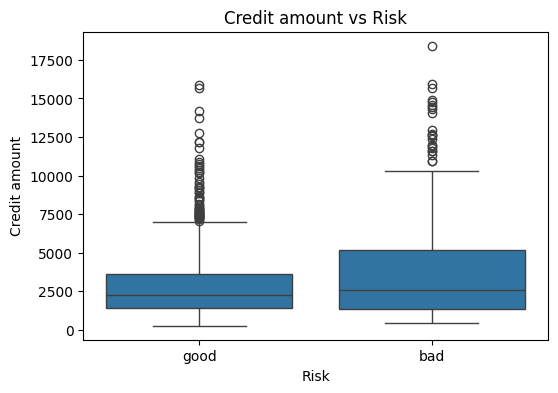

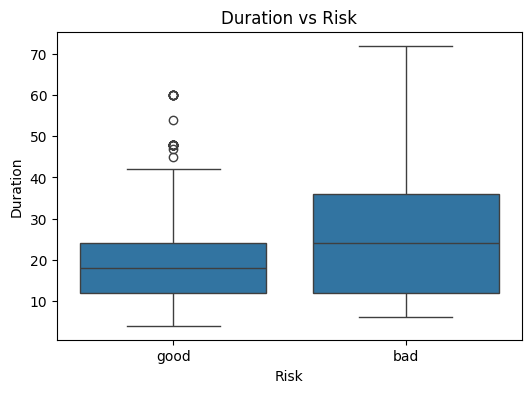

In [134]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Risk', y=col, data=df)
    plt.title(f"{col} vs Risk")
    plt.show()

DATA PREPROCESSING AND CLEANING

In [135]:
#Copy Dataset

df_clean = df.copy()

In [136]:
#Missing Value Treatment
df_clean.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [137]:
df_clean['Saving accounts'].fillna(df_clean['Saving accounts'].mode()[0], inplace=True)
df_clean['Checking account'].fillna(df_clean['Checking account'].mode()[0], inplace=True)

C:\Users\Anurag Patel\AppData\Local\Temp\ipykernel_21436\1198809208.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Saving accounts'].fillna(df_clean['Saving accounts'].mode()[0], inplace=True)
C:\Users\Anurag Patel\AppData\Local\Temp\ipykernel_21436\1198809208.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

In [138]:
df_clean.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

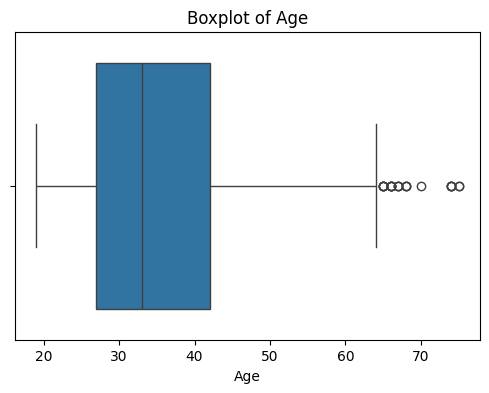

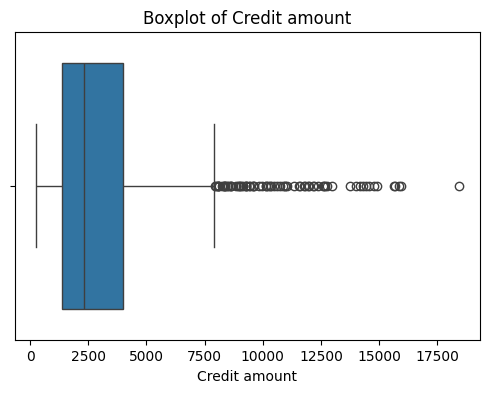

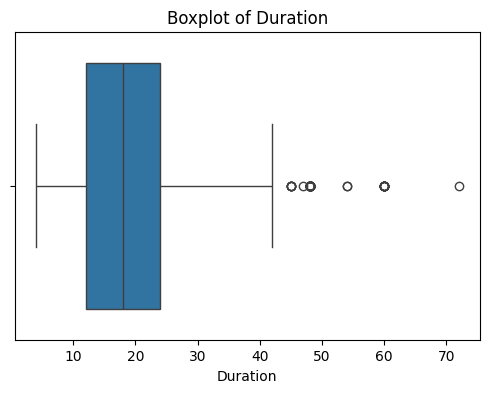

In [139]:
numeric_cols = ['Age', 'Credit amount', 'Duration']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


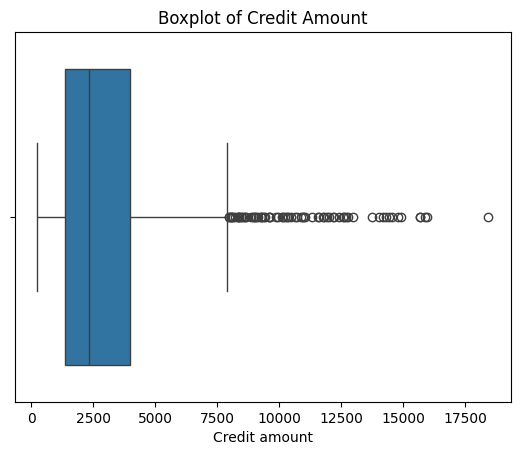

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_clean['Credit amount'])
plt.title("Boxplot of Credit Amount")
plt.show()

In [141]:
#Outlier Handling(IQR Method)

def remove_outliers_iqr(df,cols):
    for col in cols:
        Q1= df[col].quantile(0.25)
        Q3= df[col].quantile(0.75)
        IQR = Q3-Q1
        lower = Q1 -1.5*IQR
        upper = Q3 + 1.5* IQR
        df[col]= np.clip(df[col],lower,upper)
    return df

df_clean = remove_outliers_iqr(df_clean,num_cols)



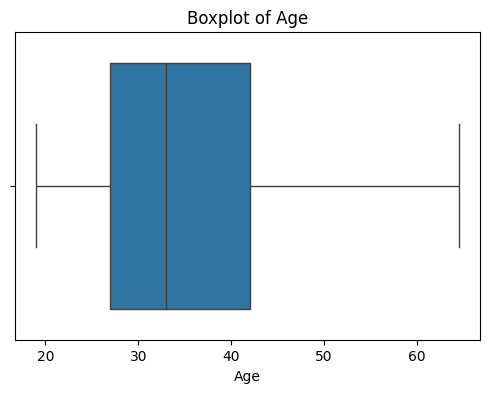

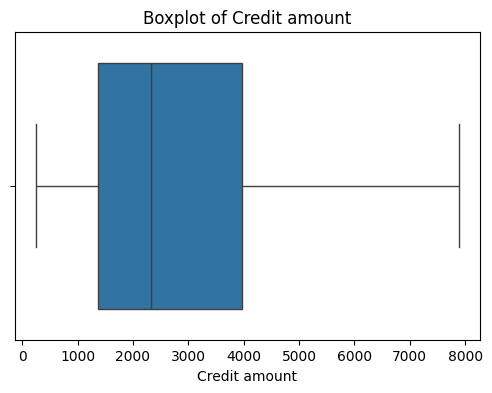

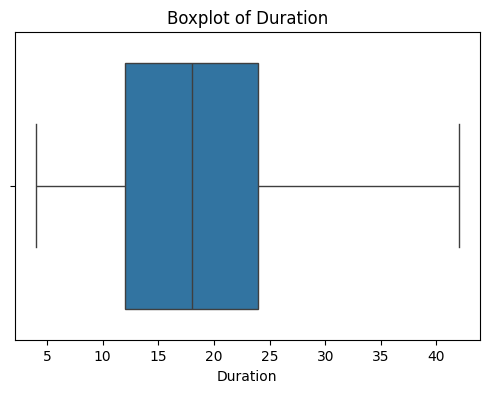

In [142]:
numeric_cols = ['Age', 'Credit amount', 'Duration']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [143]:
df_clean['Risk'].unique()

array(['good', 'bad'], dtype=object)

In [144]:
#target variable encoding

df_clean['Risk'] = (
    df_clean['Risk']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '', regex=True)
    .map({'good': 0, 'bad': 1})
)

In [145]:
print(df_clean.dtypes)
print(df_clean[['Sex','Housing','Purpose','Saving accounts','Checking account']].head())

Unnamed: 0            int64
Age                 float64
Sex                  object
Job                   int64
Housing              object
Saving accounts      object
Checking account     object
Credit amount       float64
Duration              int64
Purpose              object
Risk                  int64
dtype: object
      Sex Housing              Purpose Saving accounts Checking account
0    male     own             radio/TV          little           little
1  female     own             radio/TV          little         moderate
2    male     own            education          little           little
3    male    free  furniture/equipment          little           little
4    male    free                  car          little           little


In [147]:
# Check for problematic values in categorical columns
categorical_cols = ['Sex','Housing','Purpose','Saving accounts','Checking account']

for col in categorical_cols:
    bad_rows = df_clean[df_clean[col].apply(lambda x: isinstance(x, (list, tuple, np.ndarray)))]
    if not bad_rows.empty:
        print(f"Column '{col}' has array-like values at rows:")
        print(bad_rows[[col]].head())


for col in categorical_cols:
    df_clean[col] = df_clean[col].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)
    df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,64.5,male,2,own,little,little,1169.0,6,radio/TV,0
1,1,22.0,female,2,own,little,moderate,5951.0,42,radio/TV,1
2,2,49.0,male,2,own,little,little,2096.0,12,education,0
3,3,45.0,male,2,free,little,little,7882.0,42,furniture/equipment,0
4,4,53.0,male,2,free,little,little,4870.0,24,car,1


In [ ]:
#  One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder

onehot_cols = ['Sex', 'Housing', 'Purpose']

onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)
onehot_encoded = onehot_encoder.fit_transform(df_clean[onehot_cols])

onehot_df = pd.DataFrame(
    onehot_encoded,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=df_clean.index
)

df_clean_encoded = pd.concat(
    [df_clean.drop(columns=onehot_cols), onehot_df],
    axis=1
)

In [ ]:
#  Ordinal Encoding

saving_map = {'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}
checking_map = {'little': 0, 'moderate': 1, 'rich': 2}

df_clean_encoded['Saving accounts'] = df_clean_encoded['Saving accounts'].replace(saving_map)
df_clean_encoded['Checking account'] = df_clean_encoded['Checking account'].replace(checking_map)

C:\Users\Anurag Patel\AppData\Local\Temp\ipykernel_21436\2143417653.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean_encoded['Saving accounts'] = df_clean_encoded['Saving accounts'].replace(saving_map)
C:\Users\Anurag Patel\AppData\Local\Temp\ipykernel_21436\2143417653.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean_encoded['Checking account'] = df_clean_encoded['Checking account'].replace(checking_map)


In [ ]:

# FINAL DATASET
print(df_clean_encoded.head())

   Unnamed: 0   Age  Job  Saving accounts  Checking account  Credit amount  \
0           0  64.5    2                0                 0         1169.0   
1           1  22.0    2                0                 1         5951.0   
2           2  49.0    2                0                 0         2096.0   
3           3  45.0    2                0                 0         7882.0   
4           4  53.0    2                0                 0         4870.0   

   Duration  Risk  Sex_male  Housing_own  Housing_rent  Purpose_car  \
0         6     0       1.0          1.0           0.0          0.0   
1        42     1       0.0          1.0           0.0          0.0   
2        12     0       1.0          1.0           0.0          0.0   
3        42     0       1.0          0.0           0.0          0.0   
4        24     1       1.0          0.0           0.0          1.0   

   Purpose_domestic appliances  Purpose_education  \
0                          0.0                0.0  

In [151]:
df_clean['Checking account'].unique()

array(['little', 'moderate', 'rich'], dtype=object)

In [152]:
type("rich")   # <class 'str'>

str

In [153]:
for col in ['Saving accounts','Checking account']:
    print(col, df_clean[col].apply(type).unique())

Saving accounts [<class 'str'>]
Checking account [<class 'str'>]


Feature/Target Split

In [158]:
x = df_clean_encoded.drop(['Risk', 'Unnamed: 0'], axis=1)
y = df_clean_encoded['Risk']

x.head(5)
x.dtypes

Age                            float64
Job                              int64
Saving accounts                  int64
Checking account                 int64
Credit amount                  float64
Duration                         int64
Sex_male                       float64
Housing_own                    float64
Housing_rent                   float64
Purpose_car                    float64
Purpose_domestic appliances    float64
Purpose_education              float64
Purpose_furniture/equipment    float64
Purpose_radio/TV               float64
Purpose_repairs                float64
Purpose_vacation/others        float64
dtype: object

In [159]:
y.value_counts()

Risk
0    700
1    300
Name: count, dtype: int64

In [160]:
y.shape
y.dtypes
y.head(5)

0    0
1    1
2    0
3    0
4    1
Name: Risk, dtype: int64

Train/Test Split

In [161]:
from sklearn.model_selection import train_test_split

# Encode first
x = df_clean_encoded.drop(['Risk', 'Unnamed: 0'], axis=1)
y = df_clean_encoded['Risk']

# Then split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)



In [162]:
print(X_train.dtypes)

Age                            float64
Job                              int64
Saving accounts                  int64
Checking account                 int64
Credit amount                  float64
Duration                         int64
Sex_male                       float64
Housing_own                    float64
Housing_rent                   float64
Purpose_car                    float64
Purpose_domestic appliances    float64
Purpose_education              float64
Purpose_furniture/equipment    float64
Purpose_radio/TV               float64
Purpose_repairs                float64
Purpose_vacation/others        float64
dtype: object


In [163]:
#Scaling on training data
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Credit amount', 'Duration']

scaler = StandardScaler()

# Fit only on training subset
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [164]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'   # 👈 automatic balancing
)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [165]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score,precision_score,recall_score,f1_score

# Predictions
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy : 0.6
Precision: 0.38095238095238093
Recall   : 0.5333333333333333
F1 Score : 0.4444444444444444
Confusion Matrix:
 [[88 52]
 [28 32]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.63      0.69       140
           1       0.38      0.53      0.44        60

    accuracy                           0.60       200
   macro avg       0.57      0.58      0.57       200
weighted avg       0.65      0.60      0.61       200


ROC-AUC Score: 0.6267857142857143


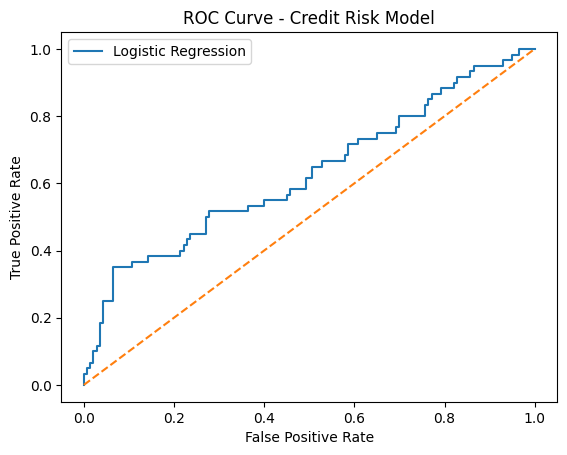

In [166]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Risk Model")
plt.legend()
plt.show()

In [167]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score,precision_score,recall_score,f1_score


# Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',   # 🔥 handles imbalance properly
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("🔹 Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

🔹 Random Forest Results
Accuracy : 0.6
Precision: 0.38095238095238093
Recall   : 0.5333333333333333
F1 Score : 0.4444444444444444

Confusion Matrix:
 [[115  25]
 [ 36  24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       140
           1       0.49      0.40      0.44        60

    accuracy                           0.69       200
   macro avg       0.63      0.61      0.62       200
weighted avg       0.68      0.69      0.69       200


ROC-AUC Score: 0.6451190476190476


In [168]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score,precision_score,recall_score,f1_score


# Handle imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,  # 🔥 imbalance handling
    random_state=42
)

# Train
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("🔹 XGBoost Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

🔹 XGBoost Results
Accuracy : 0.6
Precision: 0.38095238095238093
Recall   : 0.5333333333333333
F1 Score : 0.4444444444444444

Confusion Matrix:
 [[104  36]
 [ 35  25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.74      0.75       140
           1       0.41      0.42      0.41        60

    accuracy                           0.65       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.65      0.65      0.65       200


ROC-AUC Score: 0.6416666666666667


In [169]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score, f1_score


# Logistic Regression metrics
log_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Recall(BAD)": recall_score(y_test, y_pred),
    "Precision(BAD)": precision_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

# Random Forest metrics
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "Recall(BAD)": recall_score(y_test, y_pred_rf),
    "Precision(BAD)": precision_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

# XGBoost metrics
xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "Recall(BAD)": recall_score(y_test, y_pred_xgb),
    "Precision(BAD)": precision_score(y_test, y_pred_xgb),
    "F1-Score": f1_score(y_test, y_pred_xgb)
}

# Create comparison table
comparison_df = pd.DataFrame([log_metrics, rf_metrics, xgb_metrics])

# Sort by ROC-AUC (main business metric)
comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

comparison_df

,Model,Accuracy,ROC-AUC,Recall(BAD),Precision(BAD),F1-Score
1,Random Forest,0.695,0.645119,0.400000,0.489796,0.440367
2,XGBoost,0.645,0.641667,0.416667,0.409836,0.413223
0,Logistic Regression,0.600,0.626786,0.533333,0.380952,0.444444


In [170]:
import joblib

best_model = xgb_model  # example
joblib.dump(best_model, "D:/Credit-Risk-Scoring-System/model/credit_risk_model.pkl")

['D:/Credit-Risk-Scoring-System/model/credit_risk_model.pkl']